In [2]:
# 🦄 Analyzing Unicorn Companies (Valued Over $1 Billion)

#This project uses **SQL** (via SQLite) to explore unicorn companies, analyze industry valuations, and identify the yearly growth of new unicorns between **2019 and 2021**.

#**Database Schema** 4 normalized tables:

#| Table | Description |
#####|---|---|
####| `companies` | Company name, city, country, continent |
###| `industries` | Industry each company belongs to |
##| `dates` | Date the company joined the unicorn club & year founded |
#| `funding` | Valuation and total funding raised |

In [3]:
# ============================================================
# 📦 Step 1 — Setup: imports, dataset, and SQLite database
# ============================================================
import pandas as pd
import sqlite3
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")

# ----------- Curated unicorn companies dataset -----------
# fmt: off
raw_unicorns = [
    # (company, valuation_B, funding_M, industry, city, country, continent, year_founded, date_joined)
    ("Bytedance",       140,  7400, "Artificial intelligence",   "Beijing",        "China",         "Asia",          2012, "2017-04-07"),
    ("SpaceX",          127, 7100,  "Other",                     "Hawthorne",      "United States", "North America", 2002, "2012-12-01"),
    ("SHEIN",            100, 2000, "E-commerce & direct-to-consumer","Shenzhen",  "China",         "Asia",          2008, "2018-07-01"),
    ("Stripe",           95, 2200,  "Fintech",                   "San Francisco",  "United States", "North America", 2010, "2014-01-23"),
    ("Klarna",           46, 3700,  "Fintech",                   "Stockholm",      "Sweden",        "Europe",        2005, "2011-12-12"),
    ("Canva",            40, 572,   "Internet software & services","Sydney",        "Australia",     "Oceania",       2012, "2018-01-08"),
    ("Checkout.com",     40, 1800,  "Fintech",                   "London",         "United Kingdom","Europe",        2012, "2019-05-02"),
    ("Databricks",       38, 3500,  "Data management & analytics","San Francisco", "United States", "North America", 2013, "2019-02-05"),
    ("Revolut",          33, 1700,  "Fintech",                   "London",         "United Kingdom","Europe",        2015, "2018-04-26"),
    ("Epic Games",       32, 5400,  "Internet software & services","Cary",         "United States", "North America", 1991, "2018-10-26"),
    ("Fanatics",         31, 3400,  "E-commerce & direct-to-consumer","Jacksonville","United States","North America", 1995, "2012-06-01"),
    ("Miro",             17.5, 476, "Internet software & services","San Francisco","United States", "North America", 2011, "2020-04-21"),
    ("Figma",            10, 333,   "Internet software & services","San Francisco","United States", "North America", 2012, "2020-04-30"),
    ("Discord",          15, 995,   "Internet software & services","San Francisco","United States", "North America", 2012, "2020-06-30"),
    ("Nubank",           30, 2800,  "Fintech",                   "São Paulo",      "Brazil",        "South America", 2013, "2018-03-01"),
    ("Rivian",           27.6,10700,"Auto & transportation",     "Irvine",         "United States", "North America", 2009, "2019-09-10"),
    ("Instacart",        39, 2700,  "Supply chain, logistics, & delivery","San Francisco","United States","North America",2012,"2014-12-30"),
    ("Plaid",            13.4,734,  "Fintech",                   "San Francisco",  "United States", "North America", 2013, "2018-12-11"),
    ("Brex",             12.3, 1200,"Fintech",                   "San Francisco",  "United States", "North America", 2017, "2019-10-04"),
    ("Rappi",            5.25, 2200,"Supply chain, logistics, & delivery","Bogotá","Colombia",      "South America", 2015, "2019-04-30"),
    ("UiPath",           35, 2100,  "Artificial intelligence",   "New York",       "United States", "North America", 2005, "2019-04-02"),
    ("Notion",           10, 343,   "Internet software & services","San Francisco","United States", "North America", 2013, "2020-04-01"),
    ("Celonis",          13, 1400,  "Data management & analytics","Munich",        "Germany",       "Europe",        2011, "2018-06-26"),
    ("Nuro",             8.6, 2100, "Auto & transportation",     "Mountain View",  "United States", "North America", 2016, "2019-02-11"),
    ("Grammarly",        13, 400,   "Artificial intelligence",   "San Francisco",  "United States", "North America", 2009, "2019-10-10"),
    ("Getir",            12, 1800,  "Supply chain, logistics, & delivery","Istanbul","Turkey",       "Europe",        2015, "2021-03-26"),
    ("Blockchain.com",   14, 490,   "Fintech",                   "London",         "United Kingdom","Europe",        2011, "2021-02-17"),
    ("Gojek",            10, 5300,  "Supply chain, logistics, & delivery","Jakarta","Indonesia",    "Asia",          2010, "2016-08-04"),
    ("Grab",             14, 12000, "Supply chain, logistics, & delivery","Singapore","Singapore",   "Asia",          2012, "2014-12-04"),
    ("OYO",              9,  3400,  "Travel",                    "Gurugram",       "India",         "Asia",          2013, "2018-09-25"),
    ("Razorpay",         7.5, 740,  "Fintech",                   "Bangalore",      "India",         "Asia",          2014, "2020-10-08"),
    ("CRED",             6.4, 980,  "Fintech",                   "Bangalore",      "India",         "Asia",          2018, "2021-04-06"),
    ("Meesho",           4.9, 1100, "E-commerce & direct-to-consumer","Bangalore", "India",         "Asia",          2015, "2021-04-05"),
    ("Zomato",           5.4, 2100, "Supply chain, logistics, & delivery","Gurugram","India",       "Asia",          2008, "2015-04-06"),
    ("BYJU'S",           22, 5500,  "Edtech",                    "Bangalore",      "India",         "Asia",          2011, "2018-07-25"),
    ("Swiggy",           10.7,3600, "Supply chain, logistics, & delivery","Bangalore","India",      "Asia",          2014, "2018-06-20"),
    ("Dream11",          8,  1500,  "Internet software & services","Mumbai",        "India",         "Asia",          2008, "2019-04-09"),
    ("Wiz",              6,  900,   "Cybersecurity",             "Tel Aviv",       "Israel",        "Asia",          2020, "2021-03-12"),
    ("Snyk",             8.5, 850,  "Cybersecurity",             "Boston",         "United States", "North America", 2015, "2020-01-22"),
    ("Lacework",         8.3, 1800, "Cybersecurity",             "San Jose",       "United States", "North America", 2015, "2021-07-28"),
    ("SentinelOne",      3.1, 700,  "Cybersecurity",             "Mountain View",  "United States", "North America", 2013, "2020-02-19"),
    ("DataRobot",        6.3, 1000, "Artificial intelligence",   "Boston",         "United States", "North America", 2012, "2019-09-17"),
    ("Scale AI",         7.3, 600,  "Artificial intelligence",   "San Francisco",  "United States", "North America", 2016, "2021-04-13"),
    ("Tempus",           8.1, 1300, "Health",                    "Chicago",        "United States", "North America", 2015, "2019-05-09"),
    ("Devoted Health",   12.6,1800, "Health",                    "Waltham",        "United States", "North America", 2017, "2021-04-21"),
    ("Ro",               7,  876,   "Health",                    "New York",       "United States", "North America", 2017, "2021-03-22"),
    ("Gopuff",           15, 3400,  "Supply chain, logistics, & delivery","Philadelphia","United States","North America",2013,"2020-10-08"),
    ("Flexport",         8,  2300,  "Supply chain, logistics, & delivery","San Francisco","United States","North America",2013,"2019-02-21"),
    ("Bolt",             8.4, 1200, "Supply chain, logistics, & delivery","Tallinn","Estonia",      "Europe",        2013, "2021-08-02"),
    ("Vinted",           4.5, 520,  "E-commerce & direct-to-consumer","Vilnius",   "Lithuania",     "Europe",        2008, "2021-05-11"),
    ("Trade Republic",   5.3, 900,  "Fintech",                   "Berlin",         "Germany",       "Europe",        2015, "2021-05-20"),
    ("N26",              9,  1800,  "Fintech",                   "Berlin",         "Germany",       "Europe",        2013, "2019-01-10"),
    ("OakNorth",         4.3, 1000, "Fintech",                   "London",         "United Kingdom","Europe",        2013, "2019-02-27"),
    ("Monzo",            4.5, 1500, "Fintech",                   "London",         "United Kingdom","Europe",        2015, "2018-10-31"),
    ("Alan",             2.7, 500,  "Health",                    "Paris",          "France",        "Europe",        2016, "2021-04-22"),
    ("Back Market",      5.7, 900,  "E-commerce & direct-to-consumer","Paris",     "France",        "Europe",        2014, "2021-05-18"),
    ("Gorillas",         3,  1300,  "Supply chain, logistics, & delivery","Berlin", "Germany",       "Europe",        2020, "2021-03-22"),
    ("Northvolt",        12, 6500,  "Other",                     "Stockholm",      "Sweden",        "Europe",        2016, "2021-06-09"),
    ("Rapyd",            15, 1000,  "Fintech",                   "London",         "United Kingdom","Europe",        2016, "2021-03-25"),
    ("Wayflyer",         1.6, 280,  "Fintech",                   "Dublin",         "Ireland",       "Europe",        2019, "2021-10-12"),
    ("Sennder",          1.4, 350,  "Supply chain, logistics, & delivery","Berlin","Germany",       "Europe",        2015, "2021-01-19"),
    ("Flutterwave",      3,  475,   "Fintech",                   "San Francisco",  "United States", "North America", 2016, "2021-03-09"),
    ("Chipper Cash",     2,  305,   "Fintech",                   "San Francisco",  "United States", "North America", 2018, "2021-05-07"),
    ("Andela",           1.5, 381,  "Internet software & services","New York",     "United States", "North America", 2014, "2021-09-29"),
    ("Kavak",            8.7, 2800, "E-commerce & direct-to-consumer","Mexico City","Mexico",       "North America", 2016, "2020-10-01"),
    ("Clip",             2,  400,   "Fintech",                   "Mexico City",    "Mexico",        "North America", 2012, "2021-06-22"),
    ("Tiendanube",       3.1, 550,  "E-commerce & direct-to-consumer","Buenos Aires","Argentina",   "South America", 2010, "2021-08-30"),
    ("MadeiraMadeira",   1.3, 600,  "E-commerce & direct-to-consumer","Curitiba", "Brazil",        "South America", 2009, "2021-01-19"),
    ("Loft",             2.9, 700,  "Fintech",                   "São Paulo",      "Brazil",        "South America", 2018, "2021-03-23"),
    ("QuintoAndar",      5.1, 700,  "Fintech",                   "São Paulo",      "Brazil",        "South America", 2013, "2019-09-11"),
    ("C6 Bank",          7,  500,   "Fintech",                   "São Paulo",      "Brazil",        "South America", 2018, "2021-06-28"),
    ("Creditas",         4.8, 870,  "Fintech",                   "São Paulo",      "Brazil",        "South America", 2012, "2020-12-16"),
    ("Wildlife Studios", 3,  260,   "Internet software & services","São Paulo",    "Brazil",        "South America", 2011, "2019-12-05"),
    ("Ebanx",            1,  430,   "Fintech",                   "Curitiba",       "Brazil",        "South America", 2012, "2019-10-16"),
    ("Bitmain",          12, 800,   "Hardware",                  "Beijing",        "China",         "Asia",          2013, "2018-07-06"),
    ("DJI",              15, 770,   "Hardware",                  "Shenzhen",       "China",         "Asia",          2006, "2015-05-06"),
    ("Yuanfudao",        15.5,3500, "Edtech",                   "Beijing",        "China",         "Asia",          2012, "2017-05-31"),
    ("Zuoyebang",        10, 2600,  "Edtech",                   "Beijing",        "China",         "Asia",          2015, "2018-07-18"),
    ("4Paradigm",        2.8, 700,  "Artificial intelligence",   "Beijing",        "China",         "Asia",          2014, "2019-12-20"),
    ("Full Truck Alliance",12,2400, "Supply chain, logistics, & delivery","Guiyang","China",        "Asia",          2017, "2018-04-24"),
    ("Lalamove",         10, 1600,  "Supply chain, logistics, & delivery","Hong Kong","China",      "Asia",          2013, "2021-02-18"),
    ("WeBank",           21, 425,   "Fintech",                   "Shenzhen",       "China",         "Asia",          2014, "2019-11-18"),
    ("Tokopedia",        7.5,3800,  "E-commerce & direct-to-consumer","Jakarta",  "Indonesia",     "Asia",          2009, "2018-12-14"),
    ("Bukalapak",        3.5,800,   "E-commerce & direct-to-consumer","Jakarta",  "Indonesia",     "Asia",          2010, "2019-01-11"),
    ("J&T Express",      20, 5500,  "Supply chain, logistics, & delivery","Jakarta","Indonesia",   "Asia",          2015, "2021-04-07"),
    ("One97 (Paytm)",    16, 3500,  "Fintech",                   "Noida",          "India",         "Asia",          2000, "2015-05-27"),
    ("Freshworks",       3.5, 400,  "Internet software & services","Chennai",      "India",         "Asia",          2010, "2018-07-31"),
    ("PolicyBazaar",     2.4, 770,  "Fintech",                   "Gurugram",       "India",         "Asia",          2008, "2018-06-12"),
    ("ShareChat",        5,  1700,  "Internet software & services","Bangalore",    "India",         "Asia",          2015, "2021-04-08"),
    ("Ola",              7.3, 3800, "Auto & transportation",     "Bangalore",      "India",         "Asia",          2011, "2014-10-28"),
    ("BharatPe",         2.85,730,  "Fintech",                   "New Delhi",      "India",         "Asia",          2018, "2021-08-23"),
    ("Cars24",           3.3, 900,  "E-commerce & direct-to-consumer","Gurugram", "India",         "Asia",          2015, "2021-09-09"),
    ("Toss",             7.4, 900,  "Fintech",                   "Seoul",          "South Korea",   "Asia",          2015, "2018-12-06"),
    ("Yanolja",          10, 1900,  "Travel",                    "Seoul",          "South Korea",   "Asia",          2005, "2019-06-14"),
    ("Coupang",          9,  3400,  "E-commerce & direct-to-consumer","Seoul",     "South Korea",   "Asia",          2010, "2014-05-28"),
    ("VNPay",            1,  300,   "Fintech",                   "Hanoi",          "Vietnam",       "Asia",          2007, "2020-10-01"),
    ("MessageBird",      3.8, 1100, "Internet software & services","Amsterdam",    "Netherlands",   "Europe",        2011, "2020-10-07"),
    ("Personio",         8.5, 1200, "Internet software & services","Munich",       "Germany",       "Europe",        2015, "2021-01-19"),
    ("Contentful",       3,  335,   "Internet software & services","Berlin",       "Germany",       "Europe",        2013, "2020-06-17"),
    ("Mambu",            4.9, 266,  "Fintech",                   "Berlin",         "Germany",       "Europe",        2011, "2021-01-07"),
]
# fmt: on

# ---------- Load into a Pandas DataFrame ----------
columns = [
    "company", "valuation_billions", "funding_millions",
    "industry", "city", "country", "continent",
    "year_founded", "date_joined"
]
df = pd.DataFrame(raw_unicorns, columns=columns)
df["date_joined"] = pd.to_datetime(df["date_joined"])
df["year_joined"] = df["date_joined"].dt.year

# ---------- Create SQLite Database & Normalized Tables ----------
conn = sqlite3.connect(":memory:")

df[["company", "city", "country", "continent"]].to_sql(
    "companies", conn, index=True, index_label="company_id", if_exists="replace"
)
df[["company", "industry"]].to_sql(
    "industries", conn, index=True, index_label="company_id", if_exists="replace"
)
dates_df = df[["company", "date_joined", "year_founded"]].copy()
dates_df["date_joined"] = dates_df["date_joined"].astype(str)
dates_df.to_sql(
    "dates", conn, index=True, index_label="company_id", if_exists="replace"
)
df[["company", "valuation_billions", "funding_millions"]].to_sql(
    "funding", conn, index=True, index_label="company_id", if_exists="replace"
)

for table in ["companies", "industries", "dates", "funding"]:
    count = pd.read_sql(f"SELECT COUNT(*) AS n FROM {table}", conn).iloc[0, 0]
    print(f"  {table:12s} → {count} rows")

print(f"\n✅ Loaded {len(df)} unicorn companies into SQLite ({len(df.industry.unique())} industries, {len(df.country.unique())} countries)")

  companies    → 100 rows
  industries   → 100 rows
  dates        → 100 rows
  funding      → 100 rows

✅ Loaded 100 unicorn companies into SQLite (13 industries, 22 countries)


## 🔍 Step 2 — SQL Analysis

### Query 1: Top 3 Industries by Average Valuation (among industries with the most unicorns 2019–2021)
Find the **three best-performing industries** based on the number of new unicorns created between 2019 and 2021 and their average valuation.

In [4]:
# QUERY 1 — Top 3 industries by number of unicorns (2019-2021) with avg valuation
query1 = """
WITH top_industries AS (
    SELECT
        i.industry,
        COUNT(*)                          AS num_unicorns,
        ROUND(AVG(f.valuation_billions), 2) AS avg_valuation_billions,
        ROUND(SUM(f.valuation_billions), 2) AS total_valuation_billions
    FROM industries  AS i
    JOIN dates       AS d ON i.company_id = d.company_id
    JOIN funding     AS f ON i.company_id = f.company_id
    WHERE CAST(STRFTIME('%Y', d.date_joined) AS INTEGER) BETWEEN 2019 AND 2021
    GROUP BY i.industry
    ORDER BY num_unicorns DESC
    LIMIT 3
)
SELECT * FROM top_industries;
"""
top3 = pd.read_sql(query1, conn)
top3

,industry,num_unicorns,avg_valuation_billions,total_valuation_billions
0,Fintech,22,7.86,172.95
1,Internet software & services,11,7.75,85.30
2,"Supply chain, logistics, & delivery",9,9.23,83.05


### Query 2: Yearly Growth of New Unicorns (2019–2021)
How many new unicorn companies were created each year? What is the average valuation by year?

In [5]:
# QUERY 2 — Yearly growth of new unicorns (2019-2021)
query2 = """
SELECT
    CAST(STRFTIME('%Y', d.date_joined) AS INTEGER) AS year_joined,
    COUNT(*)                                       AS new_unicorns,
    ROUND(AVG(f.valuation_billions), 2)            AS avg_valuation_billions,
    ROUND(SUM(f.valuation_billions), 2)            AS total_valuation_billions
FROM dates   AS d
JOIN funding AS f ON d.company_id = f.company_id
WHERE CAST(STRFTIME('%Y', d.date_joined) AS INTEGER) BETWEEN 2019 AND 2021
GROUP BY year_joined
ORDER BY year_joined;
"""
yearly_growth = pd.read_sql(query2, conn)
yearly_growth

,year_joined,new_unicorns,avg_valuation_billions,total_valuation_billions
0,2019,21,12.85,269.85
1,2020,13,8.30,107.90
2,2021,34,6.34,215.45


### Query 3: Top 10 Highest-Valued Unicorn Companies
Which individual companies have the highest valuations?

In [6]:
# QUERY 3 — Top 10 highest-valued unicorns
query3 = """
SELECT
    c.company,
    i.industry,
    f.valuation_billions,
    f.funding_millions,
    c.country,
    d.date_joined,
    d.year_founded
FROM companies  AS c
JOIN industries AS i ON c.company_id = i.company_id
JOIN funding    AS f ON c.company_id = f.company_id
JOIN dates      AS d ON c.company_id = d.company_id
ORDER BY f.valuation_billions DESC
LIMIT 10;
"""
top10 = pd.read_sql(query3, conn)
top10

,company,industry,valuation_billions,funding_millions,country,date_joined,year_founded
0,Bytedance,Artificial intelligence,140.0,7400,China,2017-04-07,2012
1,SpaceX,Other,127.0,7100,United States,2012-12-01,2002
2,SHEIN,E-commerce & direct-to-consumer,100.0,2000,China,2018-07-01,2008
3,Stripe,Fintech,95.0,2200,United States,2014-01-23,2010
4,Klarna,Fintech,46.0,3700,Sweden,2011-12-12,2005
5,Canva,Internet software & services,40.0,572,Australia,2018-01-08,2012
6,Checkout.com,Fintech,40.0,1800,United Kingdom,2019-05-02,2012
7,Instacart,"Supply chain, logistics, & delivery",39.0,2700,United States,2014-12-30,2012
8,Databricks,Data management & analytics,38.0,3500,United States,2019-02-05,2013
9,UiPath,Artificial intelligence,35.0,2100,United States,2019-04-02,2005


### Query 4: Unicorn Distribution by Continent & Country
Where are unicorns concentrated geographically?

In [7]:
# QUERY 4 — Distribution by continent & top countries
query4 = """
SELECT
    c.continent,
    c.country,
    COUNT(*)                              AS num_unicorns,
    ROUND(AVG(f.valuation_billions), 2)   AS avg_valuation_billions,
    ROUND(SUM(f.valuation_billions), 2)   AS total_valuation_billions
FROM companies  AS c
JOIN funding    AS f ON c.company_id = f.company_id
GROUP BY c.continent, c.country
ORDER BY num_unicorns DESC;
"""
geo = pd.read_sql(query4, conn)
geo

,continent,country,num_unicorns,avg_valuation_billions,total_valuation_billions
0,North America,United States,29,21.21,615.10
1,Asia,India,15,7.62,114.25
2,Asia,China,10,33.83,338.30
3,Europe,Germany,8,6.01,48.10
4,South America,Brazil,8,6.89,55.10
5,Europe,United Kingdom,6,18.47,110.80
6,Asia,Indonesia,4,10.25,41.00
7,Asia,South Korea,3,8.80,26.40
8,Europe,France,2,4.20,8.40
9,Europe,Sweden,2,29.00,58.00


### Query 5: Industry Breakdown per Year (2019–2021) for the Top 3 Industries
How do the top 3 industries trend year over year?

In [8]:
# QUERY 5 — Year-over-year breakdown for the top 3 industries (2019-2021)
query5 = """
WITH top3 AS (
    SELECT i.industry
    FROM industries  AS i
    JOIN dates       AS d ON i.company_id = d.company_id
    WHERE CAST(STRFTIME('%Y', d.date_joined) AS INTEGER) BETWEEN 2019 AND 2021
    GROUP BY i.industry
    ORDER BY COUNT(*) DESC
    LIMIT 3
)
SELECT
    CAST(STRFTIME('%Y', d.date_joined) AS INTEGER) AS year_joined,
    i.industry,
    COUNT(*)                                       AS num_unicorns,
    ROUND(AVG(f.valuation_billions), 2)            AS avg_valuation_billions
FROM industries AS i
JOIN dates      AS d ON i.company_id = d.company_id
JOIN funding    AS f ON i.company_id = f.company_id
WHERE i.industry IN (SELECT industry FROM top3)
  AND CAST(STRFTIME('%Y', d.date_joined) AS INTEGER) BETWEEN 2019 AND 2021
GROUP BY year_joined, i.industry
ORDER BY year_joined, num_unicorns DESC;
"""
industry_trend = pd.read_sql(query5, conn)
industry_trend

,year_joined,industry,num_unicorns,avg_valuation_billions
0,2019,Fintech,7,13.24
1,2019,"Supply chain, logistics, & delivery",2,6.63
2,2019,Internet software & services,2,5.50
3,2020,Internet software & services,6,9.88
4,2020,Fintech,3,4.43
5,2020,"Supply chain, logistics, & delivery",1,15.00
6,2021,Fintech,12,5.58
7,2021,"Supply chain, logistics, & delivery",6,9.13
8,2021,Internet software & services,3,5.00


---
## 📊 Step 3 — Visualizations

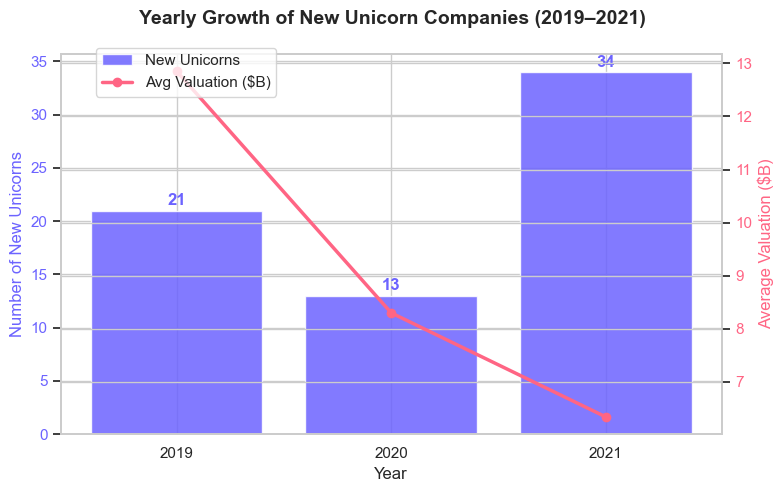

In [9]:
# ---------- Chart 1: Yearly Growth of New Unicorns ----------
fig, ax1 = plt.subplots(figsize=(8, 5))

color_bar = "#6C63FF"
color_line = "#FF6584"

bars = ax1.bar(
    yearly_growth["year_joined"].astype(str),
    yearly_growth["new_unicorns"],
    color=color_bar, alpha=0.85, label="New Unicorns"
)
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Number of New Unicorns", fontsize=12, color=color_bar)
ax1.tick_params(axis="y", labelcolor=color_bar)

# Add count labels on bars
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             int(bar.get_height()), ha="center", fontweight="bold", color=color_bar)

ax2 = ax1.twinx()
ax2.plot(
    yearly_growth["year_joined"].astype(str),
    yearly_growth["avg_valuation_billions"],
    color=color_line, marker="o", linewidth=2.5, label="Avg Valuation ($B)"
)
ax2.set_ylabel("Average Valuation ($B)", fontsize=12, color=color_line)
ax2.tick_params(axis="y", labelcolor=color_line)

fig.suptitle("Yearly Growth of New Unicorn Companies (2019–2021)", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()

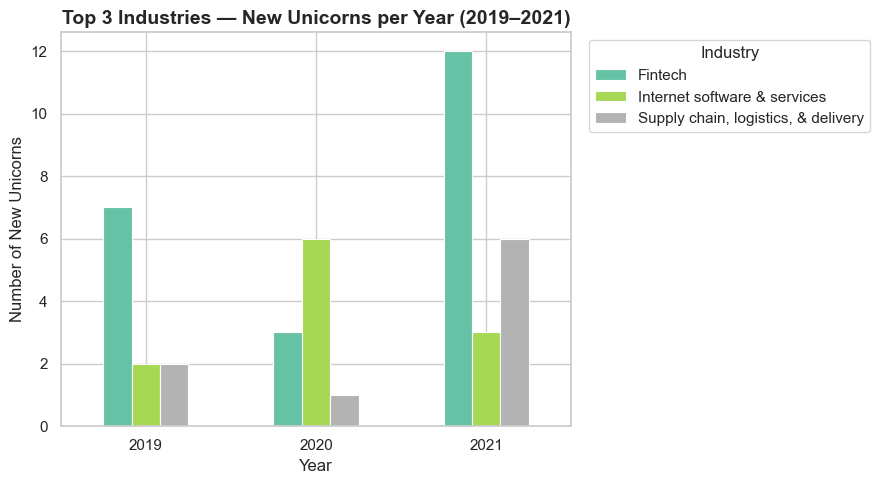

In [10]:
# ---------- Chart 2: Top 3 Industries — Unicorn Count by Year ----------
pivot = industry_trend.pivot(index="year_joined", columns="industry", values="num_unicorns").fillna(0)

pivot.plot(kind="bar", figsize=(9, 5), colormap="Set2", edgecolor="white", linewidth=0.8)
plt.title("Top 3 Industries — New Unicorns per Year (2019–2021)", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of New Unicorns", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Industry", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

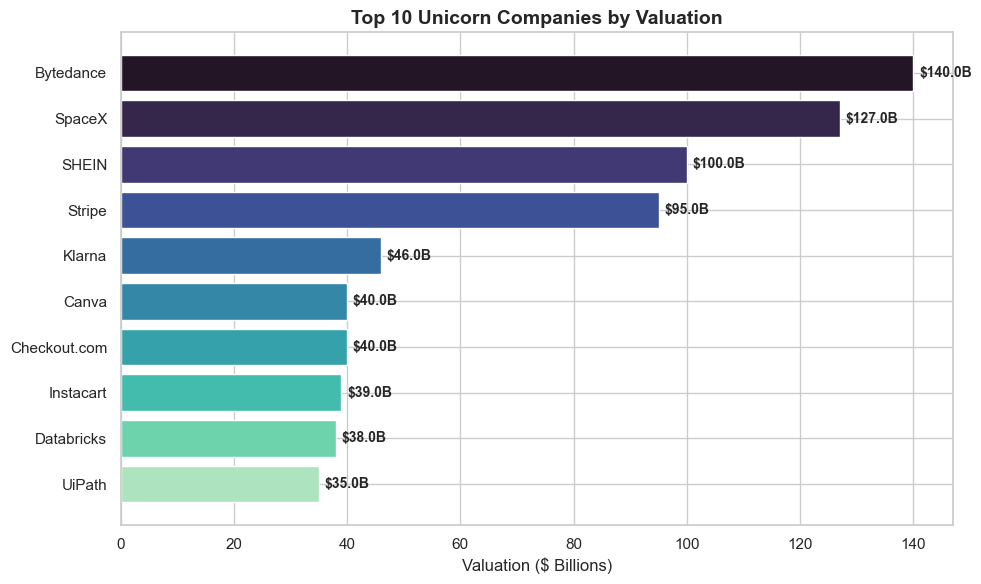

In [11]:
# ---------- Chart 3: Top 10 Unicorns by Valuation ----------
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("mako", n_colors=len(top10))

bars = ax.barh(top10["company"], top10["valuation_billions"], color=palette)
ax.invert_yaxis()
ax.set_xlabel("Valuation ($ Billions)", fontsize=12)
ax.set_title("Top 10 Unicorn Companies by Valuation", fontsize=14, fontweight="bold")

for bar, val in zip(bars, top10["valuation_billions"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"${val}B", va="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

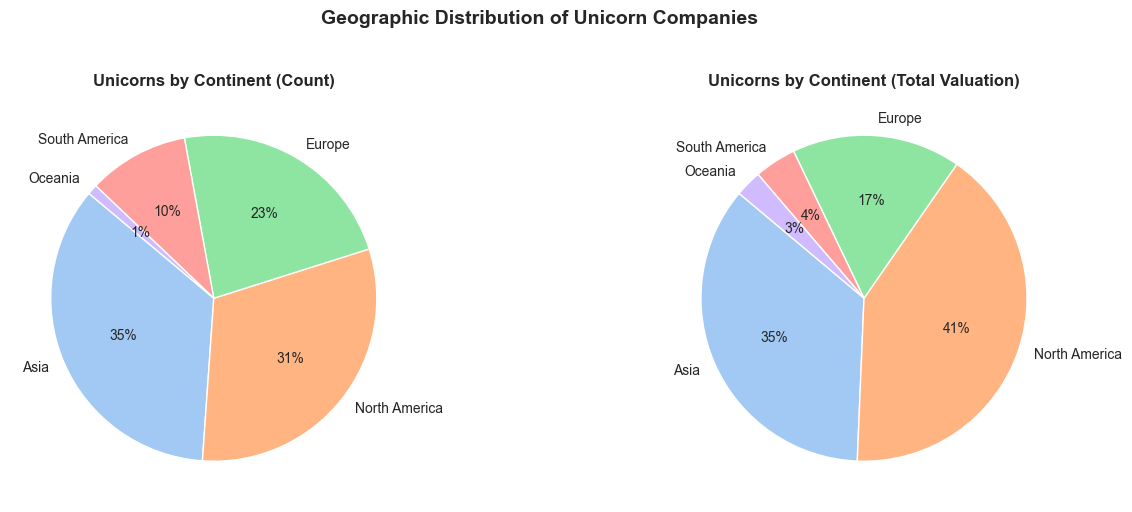

In [12]:
# ---------- Chart 4: Unicorn Distribution by Continent ----------
continent_data = geo.groupby("continent").agg(
    num_unicorns=("num_unicorns", "sum"),
    total_valuation=("total_valuation_billions", "sum")
).sort_values("num_unicorns", ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — count
colors = sns.color_palette("pastel", n_colors=len(continent_data))
ax1.pie(continent_data["num_unicorns"], labels=continent_data.index,
        autopct="%1.0f%%", colors=colors, startangle=140, textprops={"fontsize": 10})
ax1.set_title("Unicorns by Continent (Count)", fontweight="bold")

# Pie chart — valuation
ax2.pie(continent_data["total_valuation"], labels=continent_data.index,
        autopct="%1.0f%%", colors=colors, startangle=140, textprops={"fontsize": 10})
ax2.set_title("Unicorns by Continent (Total Valuation)", fontweight="bold")

plt.suptitle("Geographic Distribution of Unicorn Companies", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 🧾 Summary & Key Findings

| Insight | Detail |
|---|---|
| **Top Industries (2019–2021)** | Fintech, Supply chain/logistics, and Internet software lead in new unicorn creation |
| **Explosive 2021 Growth** | 2021 saw the most new unicorns — a massive spike vs. 2019 and 2020 |
| **Highest Valued** | Bytedance ($140B), SpaceX ($127B), and SHEIN ($100B) top the chart |
| **Geography** | North America and Asia dominate both in count and total valuation |
| **Fintech Dominance** | Fintech is the single largest industry across all years |

### 💡 Next Steps
- Expand the dataset with more companies for deeper analysis
- Analyze **time-to-unicorn** (years from founding to $1B valuation)
- Compare **funding efficiency** (valuation / funding raised)
- Build an interactive dashboard with Plotly or Streamlit